## **SNAP Jupyter demo notebook**
**SAR speckle filter showcase — visual and quantitative comparison**

In summary, this workflow contains:

- Background on speckle and why SAR images need filtering
- Preprocess a single Sentinel-1 GRD scene (calibration + terrain correction)
- Apply nine single-channel speckle filters: Boxcar, Median, Frost, Gamma Map, Lee, Refined Lee, Lee Sigma, IDAN, MuLoG
- Visual side-by-side grid + quantitative comparison via **Equivalent Number of Looks (ENL)** measured over a homogeneous patch

Complexity: intermediate

##### ***About the test data:***

A small **Sentinel-1 Stripmap (SM) GRDH** subset (single-pol **HH**, 412 x 280 px) is bundled in
`data/`, so this notebook runs out of the box - no download or Copernicus account needed (same
convention as the OLCI demo notebooks).

To try your own scene, drop any Sentinel-1 GRD product (e.g. `S1*_IW_GRDH_1S*` from the
[Copernicus Browser](https://dataspace.copernicus.eu/browser/)) into `data/` and update
`grd_product` / `polarisation` in the *Configure input paths* cell. A scene with both a homogeneous
patch (water, bare field) and structured features (urban, roads) is ideal for the ENL metric and
edge-preservation comparison.

##### ***Some information on the Python environment:***

In [1]:
import os
import sys
print("Python version: " + sys.version)

import sysconfig
print("Location of esa_snappy package: " + sysconfig.get_paths()['purelib'] + os.sep + "esa_snappy")

Python version: 3.13.13 (tags/v3.13.13:01104ce, Apr  7 2026, 19:25:48) [MSC v.1944 64 bit (AMD64)]
Location of esa_snappy package: C:\Users\luis_\AppData\Local\Programs\Python\Python313\Lib\site-packages\esa_snappy


##### ***Import Python packages...***

In [2]:
import esa_snappy
from esa_snappy import ProductIO

import snapista
from snapista import Graph
from snapista import Operator

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

##### ***Plot helpers (with ENL):***

In [3]:
def _read_band(product, name):
    band = product.getBand(name)
    if band is None:
        raise KeyError(f"Band {name!r} not found. Available: {[b.getName() for b in product.getBands()]}")
    w, h = band.getRasterWidth(), band.getRasterHeight()
    data = np.zeros(w * h, np.float32)
    band.readPixels(0, 0, w, h, data)
    data.shape = h, w
    return data

def plot_grid(images, titles, suptitle=None, cmap='gray', vmin=None, vmax=None, ncols=3):
    """Plot a list of 2D arrays in a grid."""
    n = len(images)
    nrows = (n + ncols - 1) // ncols
    fig, axs = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
    axs = np.array(axs).reshape(-1)
    for ax, img, title in zip(axs, images, titles):
        ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.set_xticks([]); ax.set_yticks([])
    for ax in axs[len(images):]:
        ax.axis('off')
    if suptitle:
        fig.suptitle(suptitle)
    plt.tight_layout()
    plt.show()

def compute_enl(data, x0, y0, w, h):
    """Equivalent Number of Looks over a (presumably homogeneous) patch."""
    patch = data[y0:y0 + h, x0:x0 + w]
    mean = np.nanmean(patch)
    var = np.nanvar(patch)
    return float(mean * mean / var) if var > 0 else float('inf')

def find_band(product, *patterns):
    names = [b.getName() for b in product.getBands()]
    for pat in patterns:
        for n in names:
            if pat.lower() in n.lower():
                return n
    raise KeyError(f"No band matching {patterns!r} found. Available: {names}")

---

### ***Background: SAR speckle***

SAR images look noisy. That "noise" is **speckle** — it's not sensor noise but interference: many independent scatterers inside each resolution cell each contribute their own complex amplitude, and the random sum gives multiplicative, Rayleigh/Gamma-distributed fluctuations. Speckle is a *signal*, not an *error*, but it makes interpretation and segmentation hard.

Filters reduce speckle by averaging over neighbouring pixels, with various strategies for preserving edges and point targets:

| Filter | Idea | Edge preservation |
|:-------|:-----|:------------------|
| **Boxcar** | uniform mean over a window | poor — blurs everything |
| **Median** | median over a window | moderate; robust to spikes/outliers |
| **Frost** | exponentially weighted by local variation | moderate |
| **Gamma Map** | Bayesian MAP assuming a Gamma-distributed scene | good |
| **Lee** | local linear minimum-MSE from local statistics | moderate |
| **Refined Lee** | direction-aware: pick a sub-window aligned with local gradient | good |
| **Lee Sigma** | mean of pixels within ±σ of the centre | good, clips outliers |
| **IDAN** | grow an irregular region of similar pixels around each centre | very good |
| **MuLoG** | non-local means in the log domain (multi-channel) | very good; strongest smoothing, slower |

We'll quantify *speckle reduction* with the **Equivalent Number of Looks** (ENL):

$$\mathrm{ENL} = \frac{\mu^2}{\sigma^2}$$

measured on a homogeneous (uniform-reflectance) patch. Higher ENL = more speckle smoothed out. Single-look GRD has ENL ≈ 1; a 5×5 boxcar boosts that toward 25 if the patch is truly homogeneous; smart filters trade some ENL for edge preservation.

---

### ***Configure input paths***

In [4]:
data_dir = os.path.join(os.getcwd(), 'data')
graphs_dir = os.path.join(os.getcwd(), 'graphs')
results_dir = os.path.join(os.getcwd(), 'results')
os.makedirs(graphs_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

# A small Sentinel-1 Stripmap (SM) GRDH subset is bundled in data/ so this notebook runs out of
# the box (same convention as the OLCI notebooks). It is single-polarisation HH and 412 x 280 px.
grd_product = os.path.join(
    data_dir,
    'subset_0_of_subset_1_of_S1A_S1_GRDH_1SDH_20150828T165902_20150828T165921_007466_00A4B2_84A5.dim')
polarisation = 'HH'

# The bundled sample is already small, so the AOI is the (near-)full subset.
aoi = {'x': 0, 'y': 0, 'w': 400, 'h': 260}

# Homogeneous patch (AOI-local coords) for the ENL metric.
enl_patch = {'x': 220, 'y': 30, 'w': 80, 'h': 80}

---
## ***Part 1 — Preprocess the GRD scene***
---

Standard GRD prep: orbit, thermal-noise removal, border-noise removal, calibration to sigma-nought, and a subset crop. We skip terrain correction for now so the filters operate in the original GRD geometry.

In [5]:
g_prep = Graph()
g_prep.add_node(operator=Operator('Read', file=grd_product), node_id='Read')
g_prep.add_node(operator=Operator('Apply-Orbit-File',
                                  orbitType='Sentinel Precise (Auto Download)',
                                  continueOnFail='true'),
                node_id='Orbit', source='Read')
g_prep.add_node(operator=Operator('ThermalNoiseRemoval',
                                  selectedPolarisations=polarisation),
                node_id='ThermalNoise', source='Orbit')
g_prep.add_node(operator=Operator('Remove-GRD-Border-Noise',
                                  selectedPolarisations=polarisation),
                node_id='BorderNoise', source='ThermalNoise')
g_prep.add_node(operator=Operator('Calibration',
                                  outputSigmaBand='true',
                                  selectedPolarisations=polarisation),
                node_id='Calib', source='BorderNoise')
g_prep.add_node(operator=Operator('Subset',
                                  region=f"{aoi['x']},{aoi['y']},{aoi['w']},{aoi['h']}"),
                node_id='Subset', source='Calib')

prep_out = os.path.join(results_dir, 'snap_nb_speckle_prep.dim')
g_prep.add_node(operator=Operator('Write', file=prep_out, formatName='BEAM-DIMAP'),
                node_id='Write', source='Subset')

g_prep.save_graph(os.path.join(graphs_dir, 'snap_nb_speckle_prep.xml'))
g_prep.run()

Processing the graph, this may take a while. Please wait...
standard output of subprocess: 
Executing processing graph
version = 2.53
11%22%33%45%56%67%.78%90% done.
standard error of subprocess: 
INFO: org.esa.snap.core.gpf.operators.tooladapter.ToolAdapterIO: Initializing external tool adapters
INFO: org.esa.snap.core.util.EngineVersionCheckActivator: Please check regularly for new updates for the best SNAP experience.
Processing finished successfully.


0

---
## ***Part 2 — Apply five filters***
---

For each filter we run a one-node graph: `Read → Speckle-Filter → Write`. The input is the already-preprocessed product from Part 1; the only thing that changes between runs is the `filter` parameter.

In [6]:
filters = [
    'Boxcar',
    'Median',
    'Frost',
    'Gamma Map',
    'Lee',
    'Refined Lee',
    'Lee Sigma',
    'IDAN',
    'MuLoG',
]

filter_outputs = {}
for f in filters:
    g = Graph()
    g.add_node(operator=Operator('Read', file=prep_out), node_id='Read')
    g.add_node(operator=Operator('Speckle-Filter',
                                 filter=f,
                                 windowSize='5x5'),
               node_id='Filter', source='Read')
    out = os.path.join(results_dir,
                       f"snap_nb_speckle_{f.replace(' ', '_').lower()}.dim")
    g.add_node(operator=Operator('Write', file=out, formatName='BEAM-DIMAP'),
               node_id='Write', source='Filter')
    g.run()
    filter_outputs[f] = out
    print(f'  done: {f}')
print('All filters done.')

Processing the graph, this may take a while. Please wait...
standard output of subprocess: 
Executing processing graph
22%45%56%67%90% done.
standard error of subprocess: 
INFO: org.esa.snap.core.gpf.operators.tooladapter.ToolAdapterIO: Initializing external tool adapters
INFO: org.esa.snap.core.util.EngineVersionCheckActivator: Please check regularly for new updates for the best SNAP experience.
[main] INFO hdf.hdflib.HDFLibrary - HDF4 library: 
[main] INFO hdf.hdflib.HDFLibrary -  successfully loaded.
[main] INFO hdf.hdf5lib.H5 - HDF5 library: 
[main] INFO hdf.hdf5lib.H5 -  successfully loaded.
Processing finished successfully.
  done: Boxcar
Processing the graph, this may take a while. Please wait...
standard output of subprocess: 
Executing processing graph
22%45%56%67%90% done.
standard error of subprocess: 
INFO: org.esa.snap.core.gpf.operators.tooladapter.ToolAdapterIO: Initializing external tool adapters
INFO: org.esa.snap.core.util.EngineVersionCheckActivator: Please check reg

---
## ***Part 3 — Visual comparison***
---

Plot the unfiltered baseline plus all five filtered results on a single grid, with a shared dB colour scale so the comparison is honest.

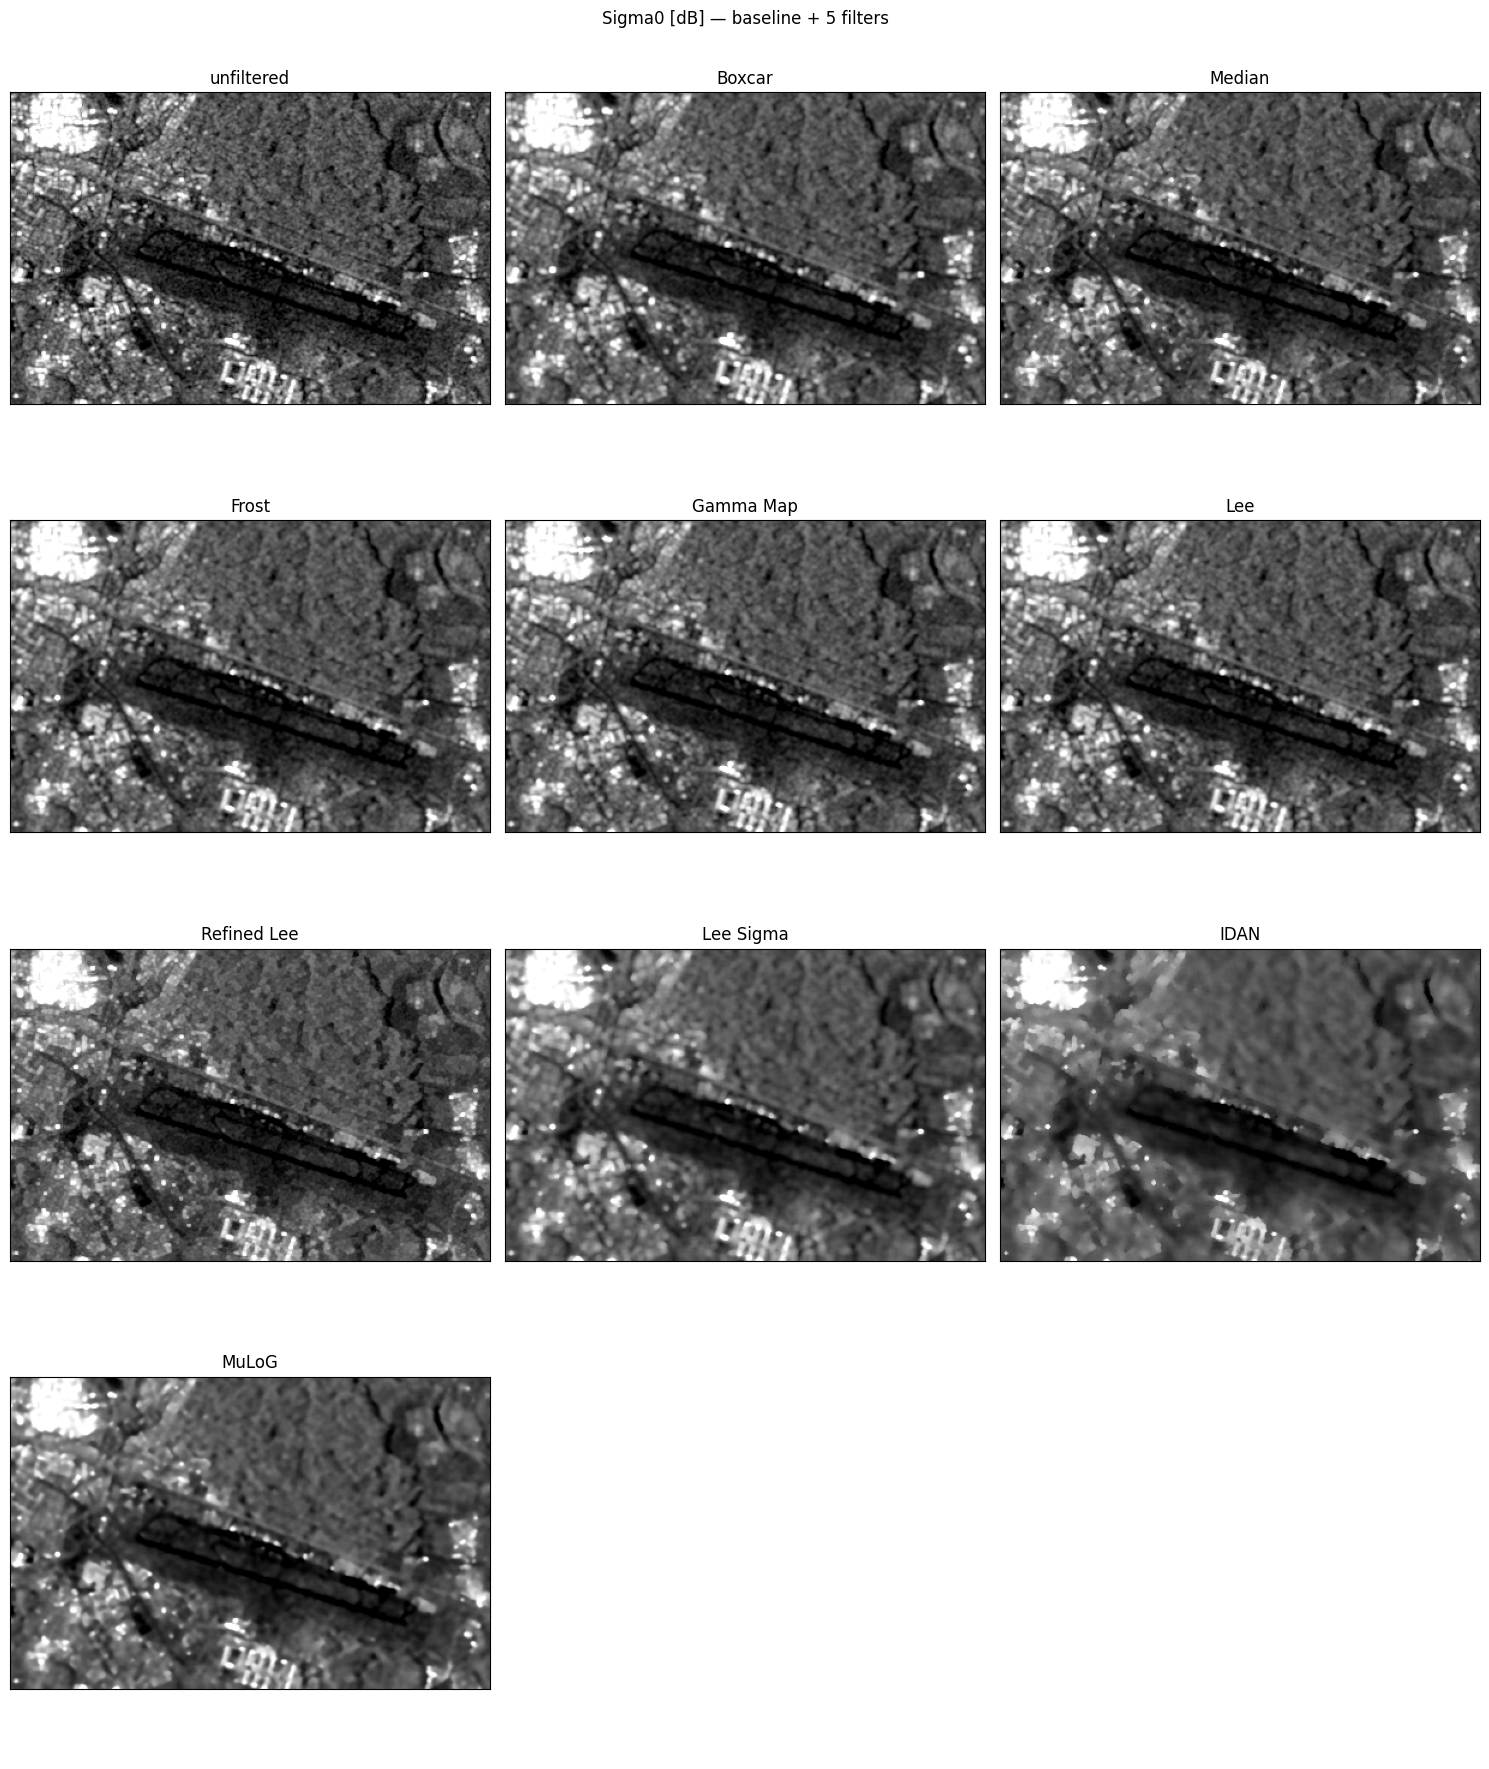

In [7]:
# Read all products and convert the Sigma0 band to dB for display
def sigma0_db(product):
    name = find_band(product, 'Sigma0')
    data = _read_band(product, name)
    data = np.maximum(data, 1e-6)
    return 10.0 * np.log10(data)

p_prep = ProductIO.readProduct(prep_out)
images = [sigma0_db(p_prep)]
titles = ['unfiltered']
loaded_products = [p_prep]
for f in filters:
    p = ProductIO.readProduct(filter_outputs[f])
    loaded_products.append(p)
    images.append(sigma0_db(p))
    titles.append(f)

# Shared dB stretch across all panels
stack = np.stack(images)
vmin = np.nanpercentile(stack, 2)
vmax = np.nanpercentile(stack, 98)
plot_grid(images, titles, suptitle='Sigma0 [dB] — baseline + 5 filters',
          cmap='gray', vmin=vmin, vmax=vmax, ncols=3)

---
## ***Part 4 — Quantitative comparison: ENL on a homogeneous patch***
---

Compute ENL on the patch defined by `enl_patch` in the *Configure* cell. Choose a patch over open water or a uniform field for a meaningful comparison.

In [8]:
# ENL is computed on linear-intensity Sigma0, not dB
def linear_sigma0(product):
    return _read_band(product, find_band(product, 'Sigma0'))

x0, y0, w, h = enl_patch['x'], enl_patch['y'], enl_patch['w'], enl_patch['h']
print(f'ENL patch: ({x0},{y0})  {w}x{h} pixels\n')
print(f"{'filter':<14s}  {'ENL':>10s}")
print('-' * 28)
enl_baseline = compute_enl(linear_sigma0(p_prep), x0, y0, w, h)
print(f"{'unfiltered':<14s}  {enl_baseline:>10.2f}")
for f, p in zip(filters, loaded_products[1:]):
    enl = compute_enl(linear_sigma0(p), x0, y0, w, h)
    print(f"{f:<14s}  {enl:>10.2f}")

for p in loaded_products:
    p.dispose()

ENL patch: (220,30)  80x80 pixels

filter                 ENL
----------------------------
unfiltered           10.94
Boxcar               17.67
Median               16.06
Frost                17.59
Gamma Map            17.67
Lee                  17.67
Refined Lee          16.60
Lee Sigma            28.30
IDAN                 43.12
MuLoG                26.45


---

### ***Summary***

What have we learnt in this notebook?

- Speckle is multiplicative interference, not sensor noise; raw GRD has ENL ≈ 1 and looks visually noisy.
- A 5×5 **Boxcar** is the upper bound on speckle reduction for a *fixed-shape* window, but it smears edges. Adaptive **region-based** (IDAN) and **non-local** (MuLoG) filters can exceed it on a homogeneous patch by pooling more same-class pixels (here IDAN and MuLoG reach the highest ENL).
- **Lee**, **Frost**, **Gamma Map** and **Refined Lee** are classic local minimum-MSE / MAP adaptive filters; **Refined Lee** adds gradient-aligned sub-windows for better edges.
- **Lee Sigma** is good when the scene has many isolated bright targets to keep; **Median** is a simple, spike-robust baseline; **MuLoG** (non-local, log-domain) gives the strongest smoothing while preserving structure, at higher compute cost.
- ENL on a homogeneous patch is the standard quantitative metric. For real applications, also measure **edge preservation** (e.g., FOM) and **point-target preservation** — a filter that maxes out ENL but blurs edges is rarely useful.